Cell 1 — Imports and Setup:

In [7]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scrublet as scr
import os
import warnings
warnings.filterwarnings('ignore')

# Set scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=True)

# Set paths
raw_dir = os.path.expanduser("~/ATRT/Data/Raw/")

# Define which samples we want and their subgroup assignments
sample_subgroups = {
    "ATRT-05":     "ATRT-SHH",
    "ATRT-15-RV4": "ATRT-TYR",
    "ATRT-173":    "ATRT-SHH",
    "ATRT-207":    "ATRT-MYC",
    "ATRT-243":    "ATRT-MYC",
    "ATRT-256":    "ATRT-SHH",
    "ATRT-340":    "ATRT-TYR",
}

print("Setup complete!")
print(f"Data directory: {raw_dir}")
print(f"Target samples: {list(sample_subgroups.keys())}")

Setup complete!
Data directory: /Users/jacquelineli/ATRT/Data/Raw/
Target samples: ['ATRT-05', 'ATRT-15-RV4', 'ATRT-173', 'ATRT-207', 'ATRT-243', 'ATRT-256', 'ATRT-340']


Cell 2 — Load count matrix and metadata:

In [8]:
# Load the metadata first to understand the structure
print("Loading metadata...")
meta = pd.read_csv(os.path.join(raw_dir, "GSE283842_ATRT_RNA_multiome_metadata.tsv.gz"), 
                   sep='\t', index_col=0)
print(f"Metadata shape: {meta.shape}")
print(f"\nMetadata columns: {meta.columns.tolist()}")
print(f"\nFirst few rows:")
meta.head()

Loading metadata...
Metadata shape: (9703, 15)

Metadata columns: ['nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rb', 'subtype', 'technology', 'Scrublet Score', 'ID', 'Phase', 'Final_Annotation', 'Final_Annotation_Focus', 'umapunintegrated_1', 'umapunintegrated_2', 'UMAPHARMONY_1', 'UMAPHARMONY_2']

First few rows:


,nCount_RNA,nFeature_RNA,percent.mt,percent.rb,subtype,technology,Scrublet Score,ID,Phase,Final_Annotation,Final_Annotation_Focus,umapunintegrated_1,umapunintegrated_2,UMAPHARMONY_1,UMAPHARMONY_2
Cell,,,,,,,,,,,,,,,
AAACAGCCAACCCTCC-1,2014,1423,4.965243,0,ATRT-MYC,10X | multiome | snRNAseq,0.031864,ATRT-MYC-4,S,Unannotated,Unannotated,-9.602942,0.200591,-0.186864,-2.013208
AAACAGCCAATATGGA-1,3431,1936,0.145730,0,ATRT-MYC,10X | multiome | snRNAseq,0.030019,ATRT-MYC-4,G1,Unannotated,Unannotated,-9.913432,0.905174,0.172659,-2.708832
AAACAGCCACGGTTTA-10,1405,875,0.071174,0,ATRT-TYR,10X | multiome | snRNAseq,0.030928,ATRT-TYR-6,G1,CP-like,CP-like,6.385612,-3.631344,6.645834,2.410110
AAACAGCCATGGCCTG-4,3776,1789,0.000000,0,ATRT-SHH,10X | multiome | snRNAseq,0.072646,ATRT-SHH-7,G1,Unannotated,Unannotated,4.308419,8.429737,1.339048,-4.387358
AAACATGCAACCCTCC-1,9735,3264,0.308166,0,ATRT-MYC,10X | multiome | snRNAseq,0.123543,ATRT-MYC-4,G2M,Unannotated,Unannotated,-8.871691,1.116294,0.764902,-2.173659


Cell 3 — Explore metadata to identify sample and cell type columns:

In [9]:
# Let's look at unique values in key columns to understand the data
print("=== Exploring metadata ===\n")
for col in meta.columns:
    n_unique = meta[col].nunique()
    print(f"{col}: {n_unique} unique values")
    if n_unique <= 30:  # Print values if there aren't too many
        print(f"  Values: {meta[col].unique().tolist()}\n")
    else:
        print(f"  (too many to list — first 5: {meta[col].unique()[:5].tolist()})\n")

=== Exploring metadata ===

nCount_RNA: 4899 unique values
  (too many to list — first 5: [2014, 3431, 1405, 3776, 9735])

nFeature_RNA: 3079 unique values
  (too many to list — first 5: [1423, 1936, 875, 1789, 3264])

percent.mt: 7229 unique values
  (too many to list — first 5: [4.96524329692155, 0.14573010784028, 0.0711743772241993, 0.0, 0.308166409861325])

percent.rb: 1 unique values
  Values: [0]

subtype: 3 unique values
  Values: ['ATRT-MYC', 'ATRT-TYR', 'ATRT-SHH']

technology: 1 unique values
  Values: ['10X | multiome | snRNAseq']

Scrublet Score: 224 unique values
  (too many to list — first 5: [0.0318635339555842, 0.0300187617260788, 0.0309278350515464, 0.0726457399103139, 0.123543123543124])

ID: 7 unique values
  Values: ['ATRT-MYC-4', 'ATRT-TYR-6', 'ATRT-SHH-7', 'ATRT-SHH-6', 'ATRT-TYR-5', 'ATRT-SHH-9', 'ATRT-SHH-8']

Phase: 3 unique values
  Values: ['S', 'G1', 'G2M']

Final_Annotation: 15 unique values
  Values: ['Unannotated', 'CP-like', 'Cilia-like', 'IPC-like', 'Ne

Cell 4 — Load the count matrix:

In [18]:
# Load the count matrix
print("Loading count matrix (this may take a few minutes)...")
counts = pd.read_csv(os.path.join(raw_dir, "GSE283842_ATRT_RNA_multiome_counts_raw.tsv.gz"), 
                     sep='\t', index_col=0)
print(f"Count matrix shape: {counts.shape}")
print(f"Rows (first 5): {counts.index[:5].tolist()}")
print(f"Columns (first 5): {counts.columns[:5].tolist()}")

# We can see: rows = 36,601 genes, columns = 9,703 cell barcodes
# Metadata index uses dashes (e.g., AAACAGCCAACCCTCC-1)
# Count matrix columns use dots (e.g., AAACAGCCAACCCTCC.1)
# Let's fix this mismatch by converting dots to dashes in count matrix columns

counts.columns = counts.columns.str.replace('.', '-', regex=False)
print(f"\nAfter barcode fix — Columns (first 5): {counts.columns[:5].tolist()}")

# Verify overlap with metadata
overlap = len(set(counts.columns) & set(meta.index))
print(f"Barcodes matching metadata: {overlap} / {len(meta)} ({overlap/len(meta)*100:.1f}%)")

Loading count matrix (this may take a few minutes)...
Count matrix shape: (36601, 9703)
Rows (first 5): ['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3']
Columns (first 5): ['AAACAGCCAACCCTCC.1', 'AAACAGCCAATATGGA.1', 'AAACAGCCACGGTTTA.10', 'AAACAGCCATGGCCTG.4', 'AAACATGCAACCCTCC.1']

After barcode fix — Columns (first 5): ['AAACAGCCAACCCTCC-1', 'AAACAGCCAATATGGA-1', 'AAACAGCCACGGTTTA-10', 'AAACAGCCATGGCCTG-4', 'AAACATGCAACCCTCC-1']
Barcodes matching metadata: 9703 / 9703 (100.0%)


Cell 5 — Create AnnData object:

In [19]:
# Genes are rows, cells are columns → transpose so cells are rows
print("Creating AnnData (genes=rows, cells=columns → transposing)...")

# Only keep barcodes that are in the metadata
shared_barcodes = list(set(counts.columns) & set(meta.index))
print(f"Shared barcodes: {len(shared_barcodes)}")

counts_filtered = counts[shared_barcodes]
print(f"Filtered count matrix: {counts_filtered.shape[0]} genes x {counts_filtered.shape[1]} cells")

# Create AnnData (transpose: cells as rows, genes as columns)
adata = sc.AnnData(
    X=counts_filtered.T.values.astype(np.float32),
    obs=pd.DataFrame(index=counts_filtered.columns),
    var=pd.DataFrame(index=counts_filtered.index)
)

# Add all metadata
meta_aligned = meta.loc[adata.obs_names]
for col in meta.columns:
    adata.obs[col] = meta_aligned[col].values

print(f"\nAnnData created: {adata.n_obs} nuclei x {adata.n_vars} genes")
print(f"\nMetadata columns: {list(adata.obs.columns)}")
print(f"\nobs preview:")
print(adata.obs.head())

# ============================================================
# KEY CHECK: This should show ~9,703 nuclei x ~36,601 genes
# and metadata should NOT be NaN
# ============================================================

Creating AnnData (genes=rows, cells=columns → transposing)...
Shared barcodes: 9703
Filtered count matrix: 36601 genes x 9703 cells

AnnData created: 9703 nuclei x 36601 genes

Metadata columns: ['nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.rb', 'subtype', 'technology', 'Scrublet Score', 'ID', 'Phase', 'Final_Annotation', 'Final_Annotation_Focus', 'umapunintegrated_1', 'umapunintegrated_2', 'UMAPHARMONY_1', 'UMAPHARMONY_2']

obs preview:
                     nCount_RNA  nFeature_RNA  percent.mt  percent.rb  \
GTTTGTAAGGTTTGAC-8         1981          1232    0.000000           0   
AGCGCTCAGAGGAGTC-1         2169          1552    1.198709           0   
TACTGACAGTTCCTCA-10        1913          1142    3.972818           0   
CACGCTAAGCCACATG-14       12415          4357    0.225534           0   
GCCACAATCTATTGTC-14        3293          1698    0.151837           0   

                      subtype                 technology  Scrublet Score  \
GTTTGTAAGGTTTGAC-8   ATRT-SHH  10X 

Cell 6 — Subset to our 7 samples and assign subgroups (UPDATE AFTER RUNNING CELL 6):

In [22]:
# The metadata 'ID' column has coded sample names like 'ATRT-MYC-4', 'ATRT-TYR-6', etc.
# Let's see them and map to the actual sample names
print("Unique IDs in metadata:")
print(adata.obs['ID'].value_counts())
print(f"\nSubtype column values:")
print(adata.obs['subtype'].value_counts())

# The 'ID' column has the sample-level identifier
# The 'subtype' column already has ATRT-MYC, ATRT-TYR, ATRT-SHH
# Since these are already our 7 samples (9,703 nuclei from the multiome dataset),
# all nuclei are from our target samples — no subsetting needed!

# Use 'ID' as the sample identifier and 'subtype' as the subgroup
adata.obs["sample"] = adata.obs["ID"].astype("category")
adata.obs["subgroup"] = adata.obs["subtype"].astype("category")

print(f"\n=== Dataset summary ===")
print(f"Total nuclei: {adata.n_obs}")
print(f"Total genes: {adata.n_vars}")
print(f"Samples: {adata.obs['sample'].nunique()}")
print(f"Subgroups: {adata.obs['subgroup'].unique().tolist()}")

print(f"\nPer-sample counts:")
for sample_id in adata.obs['sample'].cat.categories:
    n = (adata.obs['sample'] == sample_id).sum()
    subgroup = adata.obs.loc[adata.obs['sample'] == sample_id, 'subgroup'].iloc[0]
    print(f"  {sample_id} ({subgroup}): {n} nuclei")

Unique IDs in metadata:
ID
ATRT-TYR-5    2560
ATRT-SHH-9    2280
ATRT-MYC-4    1590
ATRT-TYR-6    1521
ATRT-SHH-6     701
ATRT-SHH-7     560
ATRT-SHH-8     491
Name: count, dtype: int64

Subtype column values:
subtype
ATRT-TYR    4081
ATRT-SHH    4032
ATRT-MYC    1590
Name: count, dtype: int64

=== Dataset summary ===
Total nuclei: 9703
Total genes: 36601
Samples: 7
Subgroups: ['ATRT-SHH', 'ATRT-MYC', 'ATRT-TYR']

Per-sample counts:
  ATRT-MYC-4 (ATRT-MYC): 1590 nuclei
  ATRT-SHH-6 (ATRT-SHH): 701 nuclei
  ATRT-SHH-7 (ATRT-SHH): 560 nuclei
  ATRT-SHH-8 (ATRT-SHH): 491 nuclei
  ATRT-SHH-9 (ATRT-SHH): 2280 nuclei
  ATRT-TYR-5 (ATRT-TYR): 2560 nuclei
  ATRT-TYR-6 (ATRT-TYR): 1521 nuclei


Cell 7 — QC metrics:

In [24]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print(f"Mitochondrial genes found: {adata.var['mt'].sum()}")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

# Print per-sample QC summary before filtering
print("\n=== Pre-filtering QC Summary Per Sample ===")
for sample_id in adata.obs['sample'].cat.categories:
    subset = adata.obs[adata.obs["sample"] == sample_id]
    subgroup = subset['subgroup'].iloc[0]
    print(f"\n{sample_id} ({subgroup}):")
    print(f"  Nuclei: {len(subset)}")
    print(f"  Median genes/nucleus: {subset['n_genes_by_counts'].median():.0f}")
    print(f"  Median UMI/nucleus: {subset['total_counts'].median():.0f}")
    print(f"  Median mito %: {subset['pct_counts_mt'].median():.2f}%")

Mitochondrial genes found: 13

=== Pre-filtering QC Summary Per Sample ===

ATRT-MYC-4 (ATRT-MYC):
  Nuclei: 1590
  Median genes/nucleus: 1690
  Median UMI/nucleus: 2810
  Median mito %: 0.27%

ATRT-SHH-6 (ATRT-SHH):
  Nuclei: 701
  Median genes/nucleus: 1649
  Median UMI/nucleus: 2960
  Median mito %: 0.17%

ATRT-SHH-7 (ATRT-SHH):
  Nuclei: 560
  Median genes/nucleus: 1820
  Median UMI/nucleus: 3550
  Median mito %: 0.02%

ATRT-SHH-8 (ATRT-SHH):
  Nuclei: 491
  Median genes/nucleus: 1380
  Median UMI/nucleus: 2226
  Median mito %: 0.12%

ATRT-SHH-9 (ATRT-SHH):
  Nuclei: 2280
  Median genes/nucleus: 1232
  Median UMI/nucleus: 1966
  Median mito %: 0.14%

ATRT-TYR-5 (ATRT-TYR):
  Nuclei: 2560
  Median genes/nucleus: 1722
  Median UMI/nucleus: 3040
  Median mito %: 0.14%

ATRT-TYR-6 (ATRT-TYR):
  Nuclei: 1521
  Median genes/nucleus: 1391
  Median UMI/nucleus: 2403
  Median mito %: 0.11%


Cell 9 — Pre-filtering violin plots (Figure 2A, Part 1):

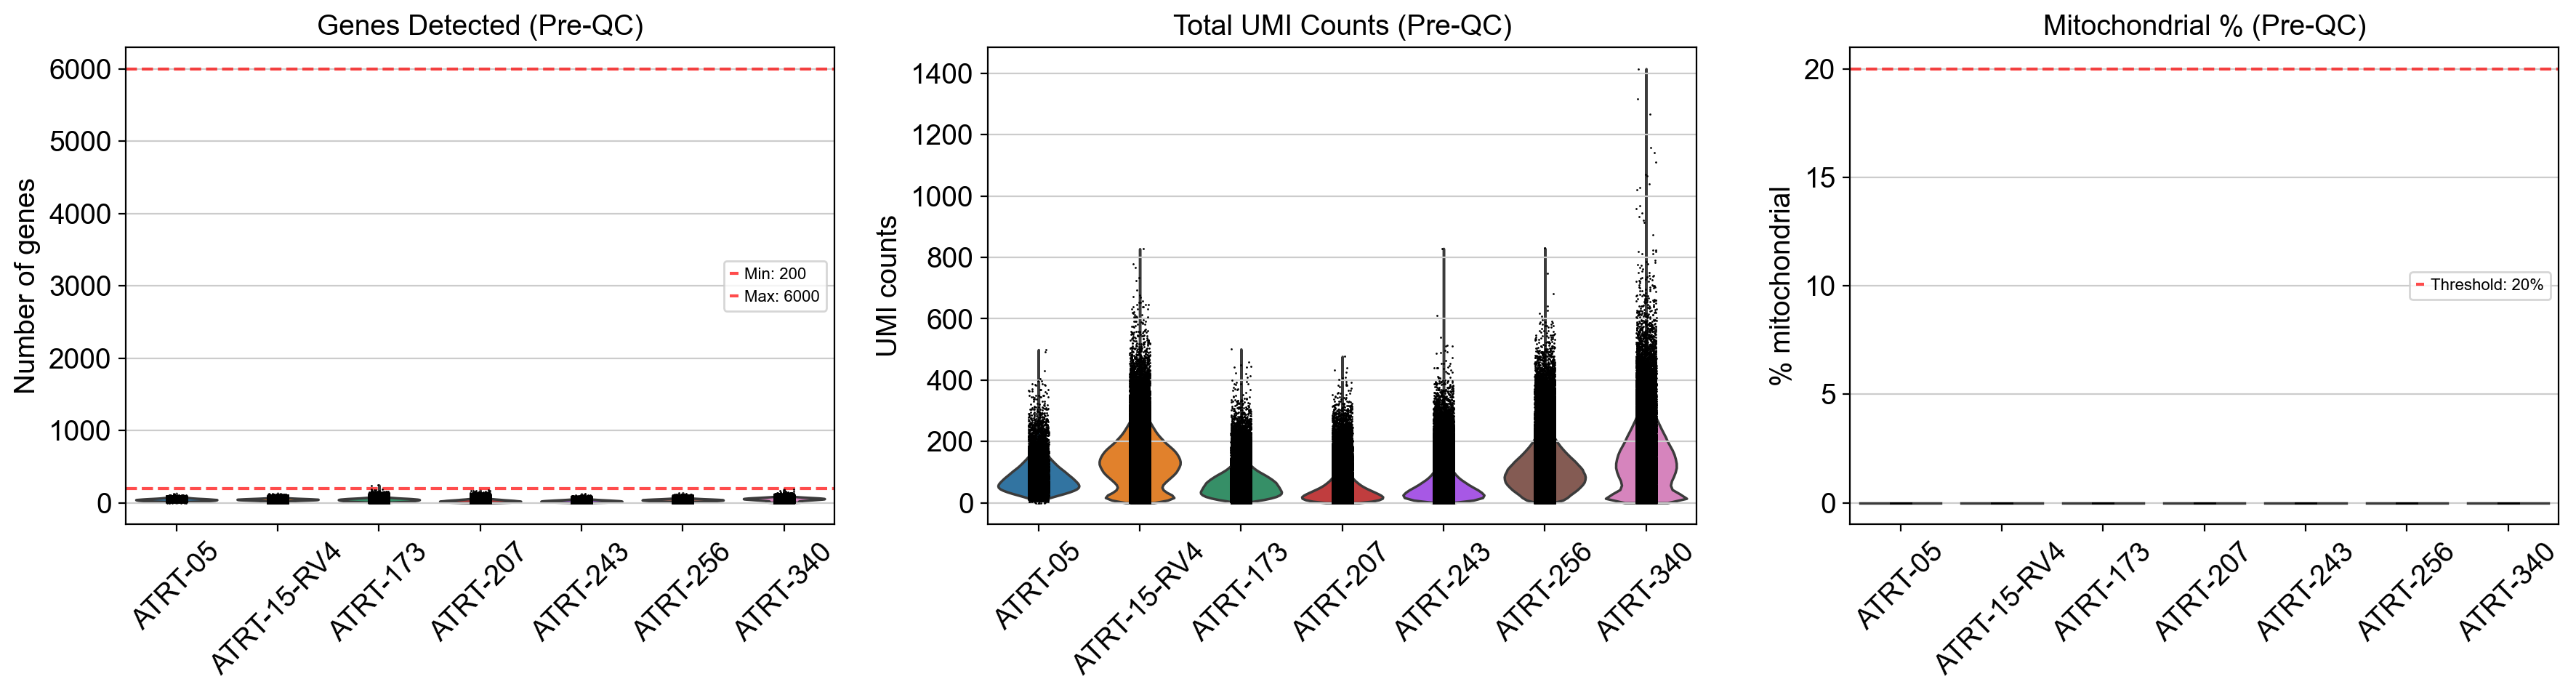


>>> FIGURE 2A (pre-QC): Saved to ~/ATRT/Data/Fig2A_pre_QC_violins.png


In [17]:
# ============================================================
# FIGURE FOR REPORT: Pre-filtering violin plots → Figure 2A
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.violin(adata, keys="n_genes_by_counts", groupby="sample", 
             rotation=45, ax=axes[0], show=False)
axes[0].set_title("Genes Detected (Pre-QC)")
axes[0].set_ylabel("Number of genes")
axes[0].axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Min: 200')
axes[0].axhline(y=6000, color='red', linestyle='--', alpha=0.7, label='Max: 6000')
axes[0].legend(fontsize=8)

sc.pl.violin(adata, keys="total_counts", groupby="sample", 
             rotation=45, ax=axes[1], show=False)
axes[1].set_title("Total UMI Counts (Pre-QC)")
axes[1].set_ylabel("UMI counts")

sc.pl.violin(adata, keys="pct_counts_mt", groupby="sample", 
             rotation=45, ax=axes[2], show=False)
axes[2].set_title("Mitochondrial % (Pre-QC)")
axes[2].set_ylabel("% mitochondrial")
axes[2].axhline(y=20, color='red', linestyle='--', alpha=0.7, label='Threshold: 20%')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2A_pre_QC_violins.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2A (pre-QC): Saved to ~/ATRT/Data/Fig2A_pre_QC_violins.png")

Cell 9 — Pre-filtering violin plots (Figure 2A):

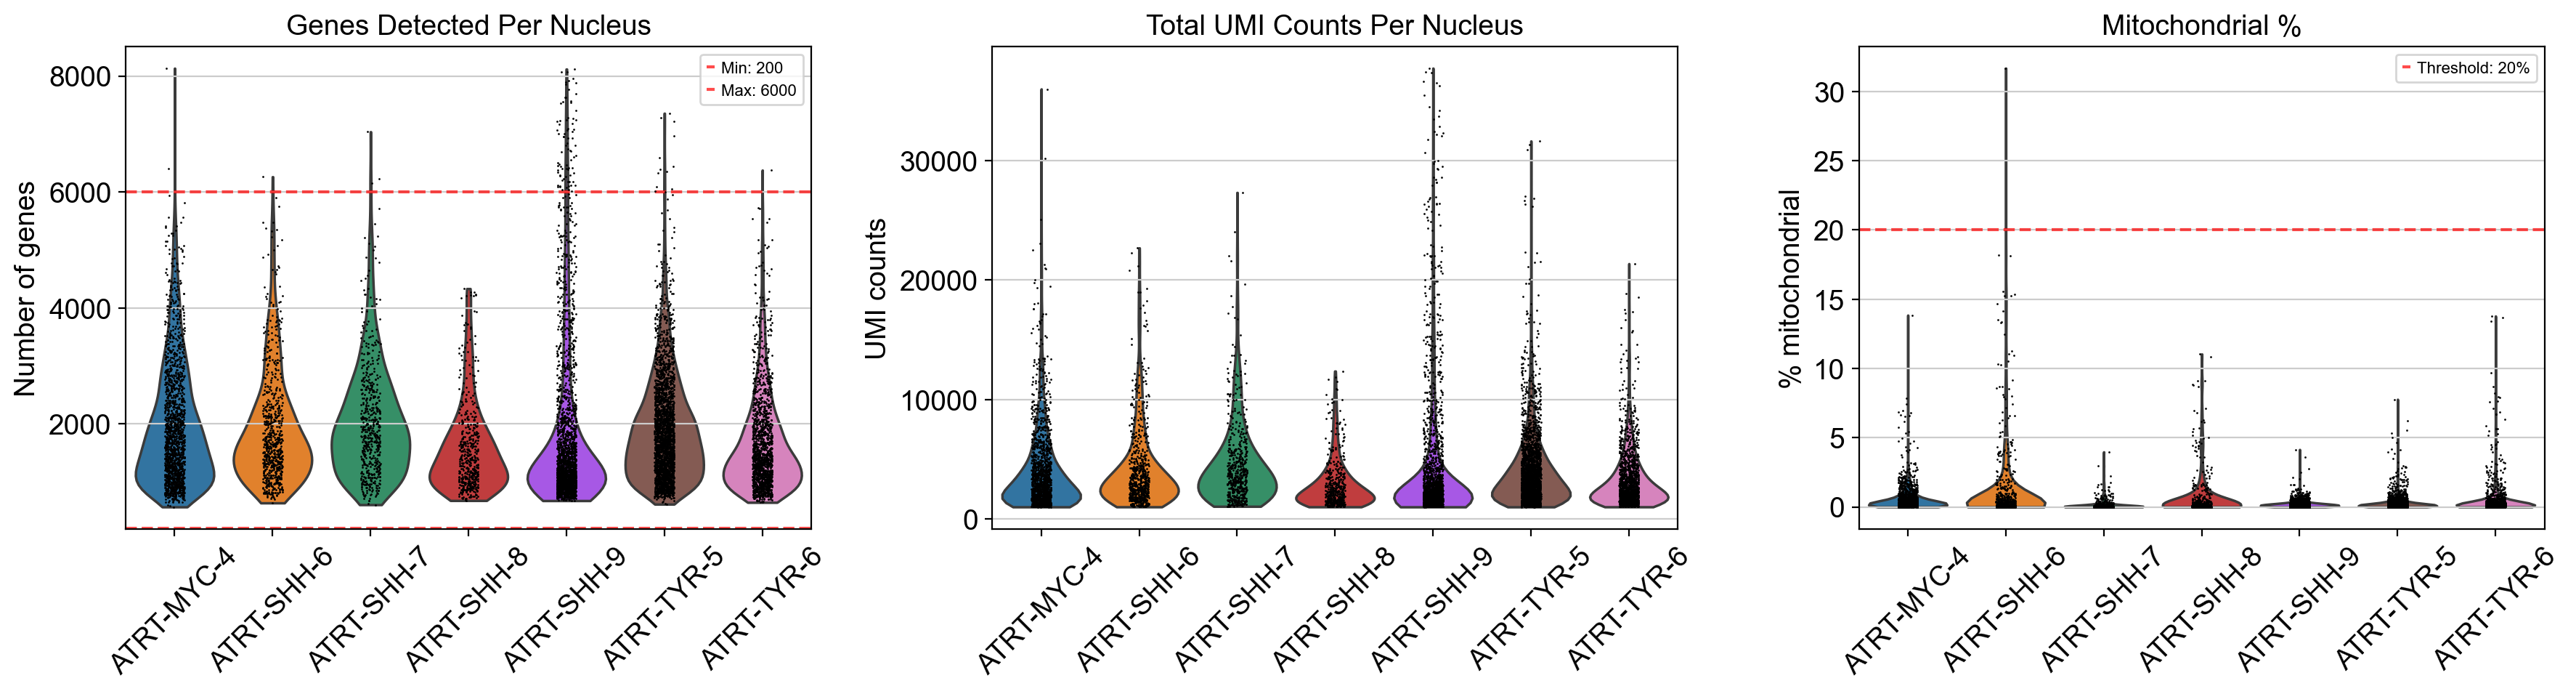


>>> FIGURE 2A: Saved to ~/ATRT/Data/Fig2A_QC_violins.png
>>> NOTE: Dataset was pre-filtered by original authors (Paassen et al.)


In [25]:
# ============================================================
# FIGURE FOR REPORT: QC violin plots → Figure 2A
# Note: This dataset was pre-filtered by the original authors.
# These plots confirm data quality post-deposition.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.violin(adata, keys="n_genes_by_counts", groupby="sample", 
             rotation=45, ax=axes[0], show=False)
axes[0].set_title("Genes Detected Per Nucleus")
axes[0].set_ylabel("Number of genes")
axes[0].axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Min: 200')
axes[0].axhline(y=6000, color='red', linestyle='--', alpha=0.7, label='Max: 6000')
axes[0].legend(fontsize=8)

sc.pl.violin(adata, keys="total_counts", groupby="sample", 
             rotation=45, ax=axes[1], show=False)
axes[1].set_title("Total UMI Counts Per Nucleus")
axes[1].set_ylabel("UMI counts")

sc.pl.violin(adata, keys="pct_counts_mt", groupby="sample", 
             rotation=45, ax=axes[2], show=False)
axes[2].set_title("Mitochondrial %")
axes[2].set_ylabel("% mitochondrial")
axes[2].axhline(y=20, color='red', linestyle='--', alpha=0.7, label='Threshold: 20%')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2A_QC_violins.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2A: Saved to ~/ATRT/Data/Fig2A_QC_violins.png")
print(">>> NOTE: Dataset was pre-filtered by original authors (Paassen et al.)")

Cell 10 — Apply light QC filtering (safety net):

In [26]:
# The deposited dataset is already QC-filtered by the authors.
# We apply the same thresholds from our Methods as a safety net,
# and use the authors' existing Scrublet scores.

n_before = adata.n_obs
print(f"Nuclei before filtering: {n_before}")

# Apply filters from Methods section
adata = adata[adata.obs["n_genes_by_counts"] >= 200, :].copy()
print(f"  After min genes (>=200): {adata.n_obs}")

adata = adata[adata.obs["n_genes_by_counts"] <= 6000, :].copy()
print(f"  After max genes (<=6000): {adata.n_obs}")

adata = adata[adata.obs["pct_counts_mt"] < 20, :].copy()
print(f"  After mito filter (<20%): {adata.n_obs}")

# Use the authors' Scrublet scores with our 0.25 threshold
adata = adata[adata.obs["Scrublet Score"] <= 0.25, :].copy()
print(f"  After doublet filter (Scrublet Score <= 0.25): {adata.n_obs}")

n_after = adata.n_obs

# ============================================================
# REPORT VALUES — fill into your Results section:
# "[X] high-quality nuclei remained across [Y] patients 
#  representing [Z] AT/RT subgroups (Figure 2A)"
# ============================================================
print(f"\n{'='*60}")
print(f">>> QC FILTERING COMPLETE")
print(f">>> Removed: {n_before - n_after} nuclei ({(n_before - n_after)/n_before*100:.1f}%)")
print(f">>> Retained: {n_after} nuclei")
print(f"{'='*60}")
print(f"\n>>> FOR REPORT (fill in Results section):")
print(f">>> X (total nuclei after QC) = {n_after}")
print(f">>> Y (patients) = {adata.obs['sample'].nunique()}")
print(f">>> Z (subgroups) = {adata.obs['subgroup'].nunique()} — {adata.obs['subgroup'].unique().tolist()}")

print(f"\n>>> Per-sample breakdown (for supplementary table):")
for sample_id in sorted(adata.obs['sample'].unique()):
    n = (adata.obs['sample'] == sample_id).sum()
    subgroup = adata.obs.loc[adata.obs['sample'] == sample_id, 'subgroup'].iloc[0]
    print(f">>>   {sample_id} ({subgroup}): {n} nuclei")

Nuclei before filtering: 9703
  After min genes (>=200): 9703
  After max genes (<=6000): 9605
  After mito filter (<20%): 9604
  After doublet filter (Scrublet Score <= 0.25): 9604

>>> QC FILTERING COMPLETE
>>> Removed: 99 nuclei (1.0%)
>>> Retained: 9604 nuclei

>>> FOR REPORT (fill in Results section):
>>> X (total nuclei after QC) = 9604
>>> Y (patients) = 7
>>> Z (subgroups) = 3 — ['ATRT-SHH', 'ATRT-MYC', 'ATRT-TYR']

>>> Per-sample breakdown (for supplementary table):
>>>   ATRT-MYC-4 (ATRT-MYC): 1588 nuclei
>>>   ATRT-SHH-6 (ATRT-SHH): 699 nuclei
>>>   ATRT-SHH-7 (ATRT-SHH): 557 nuclei
>>>   ATRT-SHH-8 (ATRT-SHH): 491 nuclei
>>>   ATRT-SHH-9 (ATRT-SHH): 2201 nuclei
>>>   ATRT-TYR-5 (ATRT-TYR): 2548 nuclei
>>>   ATRT-TYR-6 (ATRT-TYR): 1520 nuclei


Cell 11 — Post-filtering violin plots:

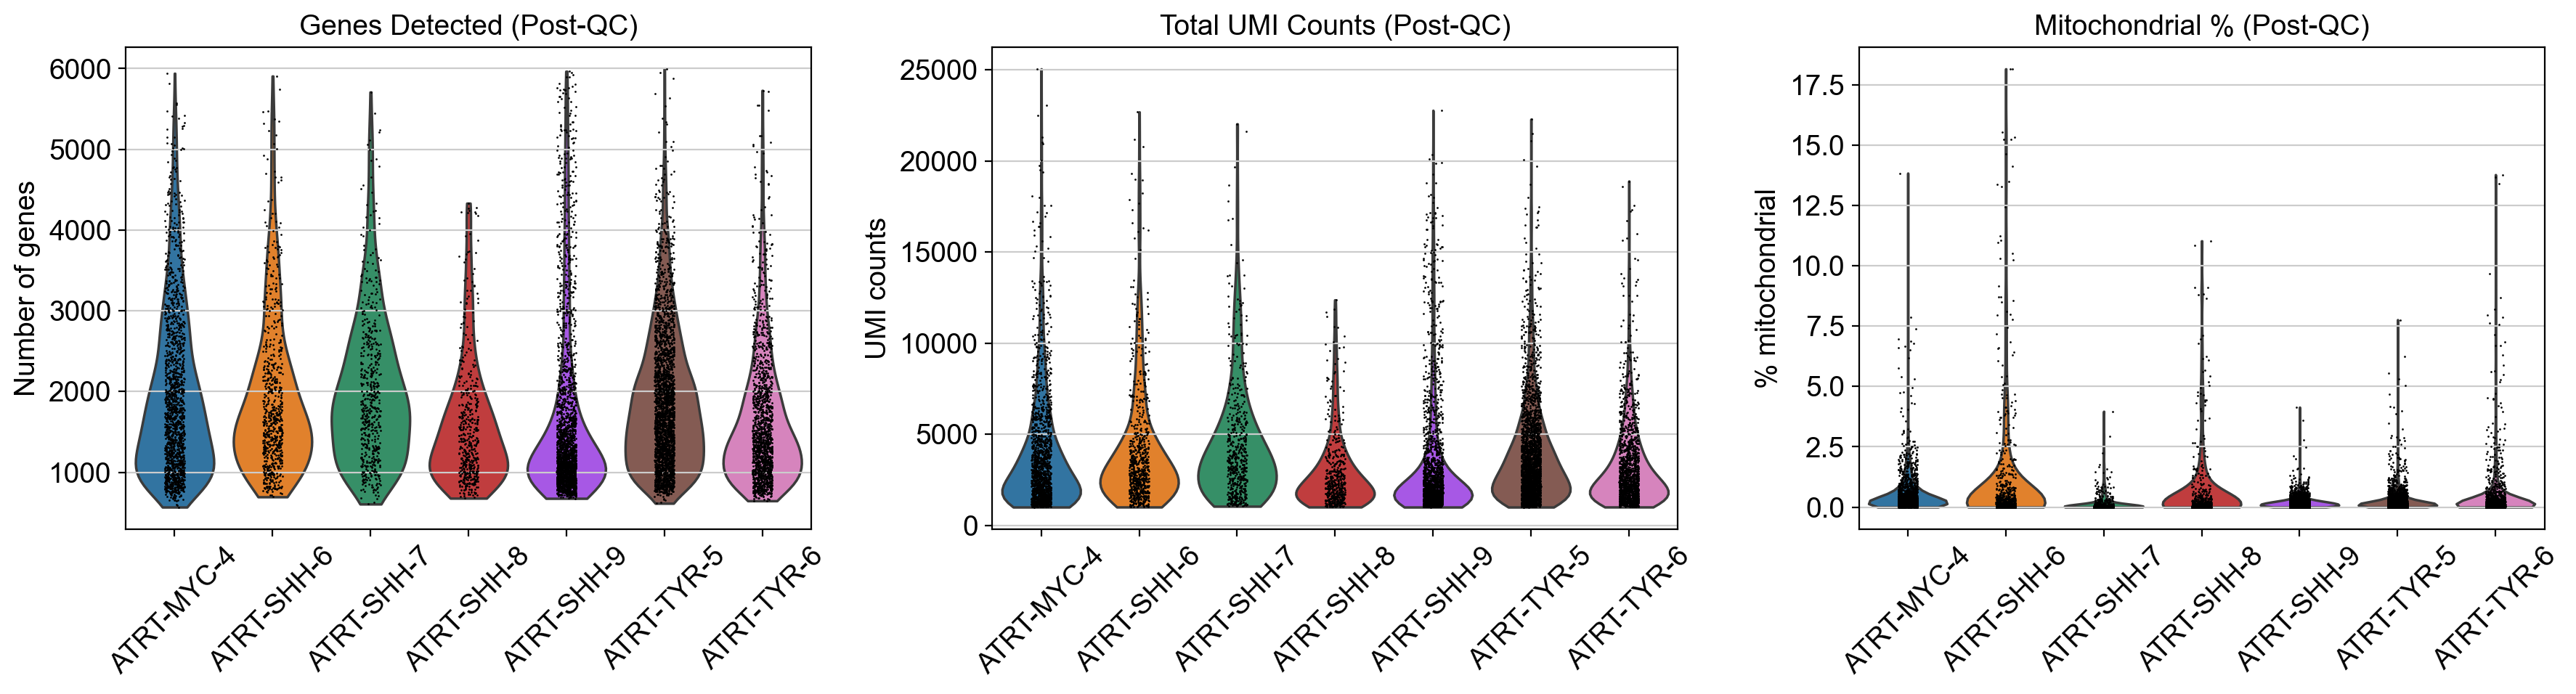


>>> FIGURE 2A (post-QC): Saved to ~/ATRT/Data/Fig2A_post_QC_violins.png


In [27]:
# ============================================================
# FIGURE FOR REPORT: Post-filtering violin plots → Figure 2A
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc.pl.violin(adata, keys="n_genes_by_counts", groupby="sample", 
             rotation=45, ax=axes[0], show=False)
axes[0].set_title("Genes Detected (Post-QC)")
axes[0].set_ylabel("Number of genes")

sc.pl.violin(adata, keys="total_counts", groupby="sample", 
             rotation=45, ax=axes[1], show=False)
axes[1].set_title("Total UMI Counts (Post-QC)")
axes[1].set_ylabel("UMI counts")

sc.pl.violin(adata, keys="pct_counts_mt", groupby="sample", 
             rotation=45, ax=axes[2], show=False)
axes[2].set_title("Mitochondrial % (Post-QC)")
axes[2].set_ylabel("% mitochondrial")

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2A_post_QC_violins.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2A (post-QC): Saved to ~/ATRT/Data/Fig2A_post_QC_violins.png")

Cell 12 — Save the QC-filtered object:

In [28]:
# Save so we don't have to redo this in the next notebook
output_path = os.path.expanduser("~/ATRT/Data/adata_QC_filtered.h5ad")
adata.write(output_path)
print(f"QC-filtered AnnData saved to: {output_path}")
print(f"Shape: {adata.n_obs} nuclei x {adata.n_vars} genes")

# Also note what metadata we're carrying forward
print(f"\nMetadata columns preserved:")
for col in adata.obs.columns:
    print(f"  {col}: {adata.obs[col].nunique()} unique values")

print(f"\n>>> Program 2 complete!")
print(f">>> Key deliverables:")
print(f">>>   - Figure 2A violin plots saved")
print(f">>>   - QC report values printed above")
print(f">>>   - adata_QC_filtered.h5ad saved for Program 3")
print(f"\n>>> Next: Program 3 (Normalization, HVG Selection & Scaling)")

QC-filtered AnnData saved to: /Users/jacquelineli/ATRT/Data/adata_QC_filtered.h5ad
Shape: 9604 nuclei x 36601 genes

Metadata columns preserved:
  nCount_RNA: 4802 unique values
  nFeature_RNA: 2984 unique values
  percent.mt: 7136 unique values
  percent.rb: 1 unique values
  subtype: 3 unique values
  technology: 1 unique values
  Scrublet Score: 224 unique values
  ID: 7 unique values
  Phase: 3 unique values
  Final_Annotation: 15 unique values
  Final_Annotation_Focus: 10 unique values
  umapunintegrated_1: 9603 unique values
  umapunintegrated_2: 9601 unique values
  UMAPHARMONY_1: 9603 unique values
  UMAPHARMONY_2: 9604 unique values
  sample: 7 unique values
  subgroup: 3 unique values
  n_genes_by_counts: 2984 unique values
  total_counts: 4802 unique values
  total_counts_mt: 213 unique values
  pct_counts_mt: 7136 unique values

>>> Program 2 complete!
>>> Key deliverables:
>>>   - Figure 2A violin plots saved
>>>   - QC report values printed above
>>>   - adata_QC_filtered